11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9269 - loss: 0.2584 - val_accuracy: 0.9596 - val_loss: 0.1381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9663 - loss: 0.1141 - val_accuracy: 0.9700 - val_loss: 0.0982
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9770 - loss: 0.0775 - val_accuracy: 0.9741 - val_loss: 0.0846
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9818 - loss: 0.0595 - val_accuracy: 0.9750 - val_loss: 0.0809
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9854 - loss: 0.0456 - val_accuracy: 0.9777 - val_loss: 0.0750
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.9741 - val_loss: 0.0896
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9766 - val_loss: 0.0743
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9931 - loss: 0.0220 

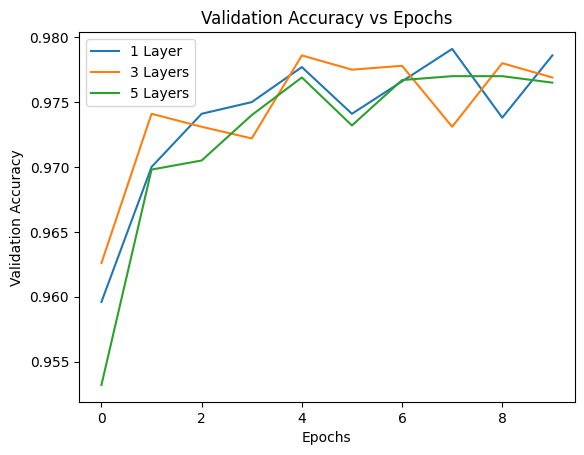

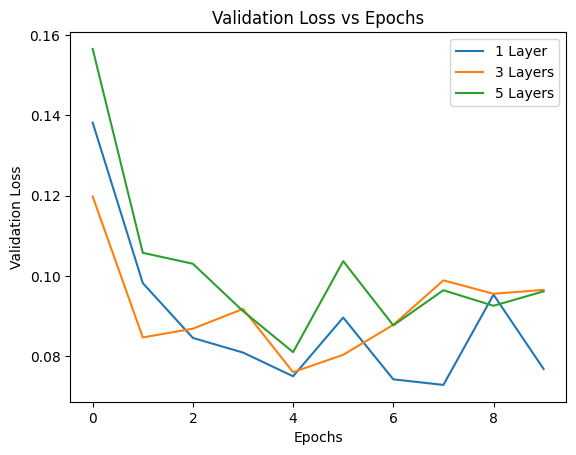

Final Results:
1 Layer -> Accuracy: 0.9786, Loss: 0.0768
3 Layers -> Accuracy: 0.9769, Loss: 0.0965
5 Layers -> Accuracy: 0.9765, Loss: 0.0962


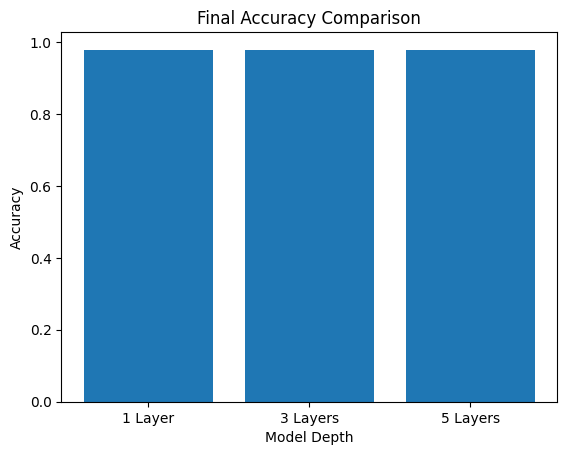

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# ==============================
# 2. LOAD DATA
# ==============================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# ==============================
# 3. BUILD MODELS (Different Depths)
# ==============================

def build_model(depth):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for _ in range(depth):
        model.add(Dense(128, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create models
model_1 = build_model(1)   # shallow
model_3 = build_model(3)   # medium
model_5 = build_model(5)   # deep

# ==============================
# 4. TRAIN MODELS
# ==============================

epochs = 10

history_1 = model_1.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)
history_3 = model_3.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)
history_5 = model_5.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)

# ==============================
# 5. PLOT ACCURACY
# ==============================

plt.figure()
plt.plot(history_1.history['val_accuracy'], label='1 Layer')
plt.plot(history_3.history['val_accuracy'], label='3 Layers')
plt.plot(history_5.history['val_accuracy'], label='5 Layers')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epochs')
plt.legend()
plt.show()

# ==============================
# 6. PLOT LOSS
# ==============================

plt.figure()
plt.plot(history_1.history['val_loss'], label='1 Layer')
plt.plot(history_3.history['val_loss'], label='3 Layers')
plt.plot(history_5.history['val_loss'], label='5 Layers')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epochs')
plt.legend()
plt.show()

# ==============================
# 7. FINAL EVALUATION
# ==============================

loss1, acc1 = model_1.evaluate(x_test, y_test, verbose=0)
loss3, acc3 = model_3.evaluate(x_test, y_test, verbose=0)
loss5, acc5 = model_5.evaluate(x_test, y_test, verbose=0)

print("Final Results:")
print(f"1 Layer -> Accuracy: {acc1:.4f}, Loss: {loss1:.4f}")
print(f"3 Layers -> Accuracy: {acc3:.4f}, Loss: {loss3:.4f}")
print(f"5 Layers -> Accuracy: {acc5:.4f}, Loss: {loss5:.4f}")

# ==============================
# 8. BAR CHART COMPARISON
# ==============================

models = ['1 Layer', '3 Layers', '5 Layers']
accuracies = [acc1, acc3, acc5]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Model Depth')
plt.ylabel('Accuracy')
plt.title('Final Accuracy Comparison')
plt.show()